#Progetto del corso - Introduzione alla Data Science e al Pensiero Computazionale - a.a 2025/2026

Gabriele Pio Girbino, matricola: 0001231583. gabriele.girbino@studio.unibo.it

Lorenzo Merlini, matricola: 0001232524. lorenzo.merlini2@studio.unibo.it

# Preparazione dell'ambiente

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Carichiamo il dataset

In [ ]:
dataset = pd.read_csv('Employee_Attrition.csv')
# Mostriamo le prime 5 righe
dataset.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Le prime righe mostrano la struttura generale dei dati.

Controlliamo le dimensioni del dataset

In [ ]:
Numero_righe = dataset.shape[0]
Numero_colonne = dataset.shape[1]
print("Il numero di dipendenti è",Numero_righe)
print("Il numero di variabili è",Numero_colonne)

Il numero di dipendenti è 1470
Il numero di variabili è 35


Il dataset contiene 1470 dipendenti e 35 variabili

#FASE 2: Descrizione e comprensione del dataset

##Domande e ipotesi

### Domanda 1: Gli straordinari aumentano il rischio di dimissioni?
I dipendenti che fanno abitualmente gli straordinari sono più inclini a lasciare l'azienda rispetto a chi non li fa?
Per rispondere, calcoliamo la percentuale di dimissioni nei due gruppi separati.

In [ ]:
# Seleziono i dipendenti che fanno straordinari e calcolo la % di dimissioni
straordinari_si = dataset[dataset['OverTime'] == 'Yes']
perc_dimissioni_si = (straordinari_si['Attrition'] == 'Yes').mean() * 100

# Seleziono i dipendenti che  non fanno straordinari e calcolo la % di dimissioni
straordinari_no = dataset[dataset['OverTime'] == 'No']
perc_dimissioni_no = (straordinari_no['Attrition'] == 'Yes').mean() * 100

# Stampo i risultati arrotondati a un decimale
print("Percentuale di dimissioni tra chi FA straordinari:", round(perc_dimissioni_si, 1), "%")
print("Percentuale di dimissioni tra chi NON FA straordinari:", round(perc_dimissioni_no, 1), "%")

Percentuale di dimissioni tra chi FA straordinari: 30.5 %
Percentuale di dimissioni tra chi NON FA straordinari: 10.4 %


I risultati mostrano una differenza evidente tra i due gruppi: tra chi fa straordinari la percentuale di dimissioni è molto più alta rispetto a chi non li fa. Questo suggerisce che gli straordinari potrebbero essere collegati a maggiore stress o insoddisfazione lavorativa, anche se da questa analisi non possiamo dire con certezza che siano la causa diretta dell’abbandono.

### Domanda 2: L'età influisce sulla decisione di lasciare l'azienda?
I dipendenti più giovani, avendo meno vincoli o cercando più opportunità di crescita, tendono a dimettersi più frequentemente rispetto ai colleghi più anziani?

In [ ]:
# Divido il dataset in due gruppi: chi se n'è andato e chi è rimasto
chi_ha_lasciato = dataset[dataset['Attrition'] == 'Yes']
chi_e_rimasto = dataset[dataset['Attrition'] == 'No']

# Calcolo l'età media dei due gruppi
eta_media_lasciato = chi_ha_lasciato['Age'].mean()
eta_media_rimasto = chi_e_rimasto['Age'].mean()

print("Età media di chi ha lasciato l'azienda:", round(eta_media_lasciato, 1), "anni")
print("Età media di chi è rimasto in azienda:", round(eta_media_rimasto, 1), "anni")

Età media di chi ha lasciato l'azienda: 33.6 anni
Età media di chi è rimasto in azienda: 37.6 anni


I risultati confermano che i dipendenti che hanno lasciato l’azienda sono mediamente più giovani rispetto a quelli rimasti. La differenza è di circa 4 anni, quindi l’età potrebbe essere una variabile rilevante per spiegare l’abbandono, anche se non basta da sola per individuare la causa delle dimissioni.


### Domanda 3: La lontananza da casa aumenta il rischio di dimissioni?
Affrontare un tragitto casa-lavoro molto lungo ogni giorno causa stress e stanchezza, portando i dipendenti a cercare un altro impiego?

In [ ]:
# Uso i due gruppi creati in precedenza
distanza_lasciato = chi_ha_lasciato['DistanceFromHome'].mean()
distanza_rimasto = chi_e_rimasto['DistanceFromHome'].mean()

print("Distanza media da casa per chi ha lasciato:", round(distanza_lasciato, 1), "km/miglia")
print("Distanza media da casa per chi è rimasto:", round(distanza_rimasto, 1), "km/miglia")

Distanza media da casa per chi ha lasciato: 10.6 km/miglia
Distanza media da casa per chi è rimasto: 8.9 km/miglia


I risultati dimostrano che chi ha lasciato l’azienda vive mediamente più lontano dal lavoro rispetto a chi è rimasto. La differenza però non è molto grande, quindi la distanza potrebbe incidere sull’abbandono, ma probabilmente va considerata insieme ad altri fattori come straordinari, stipendio e soddisfazione lavorativa.

### Domanda 4: Chi ha uno stipendio più basso tende a licenziarsi di più?
Un reddito mensile inferiore alla media aziendale è una delle cause principali di insoddisfazione e spinge i lavoratori verso altre aziende?

In [ ]:
# Calcolo lo stipendio medio mensile per i due gruppi
stipendio_lasciato = chi_ha_lasciato['MonthlyIncome'].mean()
stipendio_rimasto = chi_e_rimasto['MonthlyIncome'].mean()

print("Stipendio medio mensile di chi ha lasciato:", round(stipendio_lasciato, 0), "dollari")
print("Stipendio medio mensile di chi è rimasto:", round(stipendio_rimasto, 0), "dollari")

Stipendio medio mensile di chi ha lasciato: 4787.0 dollari
Stipendio medio mensile di chi è rimasto: 6833.0 dollari


I dipendenti che hanno lasciato l’azienda hanno uno stipendio medio mensile più basso rispetto a quelli rimasti. La differenza è abbastanza marcata, quindi il reddito potrebbe essere un fattore importante nell’abbandono.

### Domanda 5: Un basso livello di soddisfazione lavorativa accelera l'abbandono?
I dipendenti che dichiarano un livello di soddisfazione basso (punteggio 1 o 2) lasciano l'azienda in percentuale maggiore rispetto a chi è molto soddisfatto (punteggio 3 o 4)?

In [ ]:
# Divido il dataset in base alla soddisfazione
soddisfazione_bassa = dataset[dataset['JobSatisfaction'] <= 2]
soddisfazione_alta = dataset[dataset['JobSatisfaction'] >= 3]

# Calcolo le percentuali di dimissioni nei due gruppi
perc_via_bassa = (soddisfazione_bassa['Attrition'] == 'Yes').mean() * 100
perc_via_alta = (soddisfazione_alta['Attrition'] == 'Yes').mean() * 100

print("Percentuale di dimissioni tra chi ha una soddisfazione BASSA (1-2):", round(perc_via_bassa, 1), "%")
print("Percentuale di dimissioni tra chi ha una soddisfazione ALTA (3-4):", round(perc_via_alta, 1), "%")

Percentuale di dimissioni tra chi ha una soddisfazione BASSA (1-2): 19.7 %
Percentuale di dimissioni tra chi ha una soddisfazione ALTA (3-4): 13.9 %


La percentuale di dimissioni è più alta tra i dipendenti con bassa soddisfazione lavorativa rispetto a quelli con soddisfazione alta. Questo suggerisce che la soddisfazione sul lavoro può essere un fattore rilevante nell’abbandono, anche se la differenza non è estremamente ampia.

### Domanda 6: La mancanza di promozioni spinge alla fuga?
I dipendenti che non ricevono una promozione da molti anni si sentono bloccati a livello di carriera e decidono di cercare opportunità di crescita altrove?

In [ ]:
# Uso i due gruppi
anni_promozione_lasciato = chi_ha_lasciato['YearsSinceLastPromotion'].mean()
anni_promozione_rimasto = chi_e_rimasto['YearsSinceLastPromotion'].mean()

print("Anni medi dall'ultima promozione per chi HA LASCIATO:", round(anni_promozione_lasciato, 1))
print("Anni medi dall'ultima promozione per chi E' RIMASTO:", round(anni_promozione_rimasto, 1))

Anni medi dall'ultima promozione per chi HA LASCIATO: 1.9
Anni medi dall'ultima promozione per chi E' RIMASTO: 2.2


Sorprendentemente, i dati smentiscono la nostra ipotesi. Chi si è dimesso è stato promosso in media più di recente. Una possibile spiegazione è che i dipendenti ottengano una promozione e poi usino il nuovo titolo lavorativo per 'rivendersi' subito sul mercato del lavoro a un'azienda concorrente.

### Domanda 7: Quali sono i ruoli lavorativi con il maggior numero assoluto di dimissioni?
Calcoliamo la Top 3 dei ruoli più colpiti.

In [ ]:
# Filtro solo i dipendenti che si sono dimessi
dimessi = dataset[dataset['Attrition'] == 'Yes']

# Conto quante persone si sono dimesse per ogni ruolo lavorativo e prendo i primi 3
top_ruoli_dimissioni = dimessi['JobRole'].value_counts().head(3)

print("I 3 ruoli lavorativi con il maggior numero assoluto di dimissioni:")
print(top_ruoli_dimissioni)

I 3 ruoli lavorativi con il maggior numero assoluto di dimissioni:
JobRole
Laboratory Technician    62
Sales Executive          57
Research Scientist       47
Name: count, dtype: int64


I ruoli con più dimissioni in valore assoluto sono Laboratory Technician, Sales Executive e Research Scientist. Questo indica che l’abbandono è più concentrato in alcune mansioni, ma il dato va interpretato con attenzione perché dipende anche da quanti dipendenti totali ci sono in ciascun ruolo.


### Domanda 8: Anche i "veterani" dell'azienda si licenziano?
Ci si aspetta che chi lascia l'azienda sia principalmente un nuovo assunto. Cerchiamo di capire qual è il numero massimo e minimo di anni trascorsi in azienda da qualcuno che ha poi rassegnato le dimissioni.

In [ ]:
# Isolo chi si è dimesso
dimessi = dataset[dataset['Attrition'] == 'Yes']

# Trovo l'anzianità massima e minima tra chi si è dimesso
max_anni_dimesso = dimessi['YearsAtCompany'].max()
min_anni_dimesso = dimessi['YearsAtCompany'].min()

print("Il dipendente che si è dimesso con più anzianità aveva:", max_anni_dimesso, "anni di servizio.")
print("Il dipendente che si è dimesso con meno anzianità aveva:", min_anni_dimesso, "anni di servizio.")

Il dipendente che si è dimesso con più anzianità aveva: 40 anni di servizio.
Il dipendente che si è dimesso con meno anzianità aveva: 0 anni di servizio.


Il valore massimo mostra che anche dipendenti con molta anzianità possono lasciare l’azienda, non solo i nuovi assunti. Allo stesso tempo, il minimo pari a 0 anni indica che alcune dimissioni avvengono già nelle prime fasi del rapporto lavorativo.

##Statistiche descrittive

### Statistica Descrittiva 1: Profilo Demografico - Età, Genere e Stato Civile
In questa prima fase tracciamo l'identikit del dipendente tipo della nostra azienda. Andiamo ad analizzare la composizione demografica calcolando l'età media, la distribuzione percentuale di uomini e donne e lo stato civile.


In [ ]:
eta_media = round(dataset['Age'].mean(), 1)
eta_min = dataset['Age'].min()
eta_max = dataset['Age'].max()

perc_maschi = round((dataset['Gender'] == 'Male').mean() * 100, 1)
perc_femmine = round((dataset['Gender'] == 'Female').mean() * 100, 1)

perc_sposati = round((dataset['MaritalStatus'] == 'Married').mean() * 100, 1)
perc_single = round((dataset['MaritalStatus'] == 'Single').mean() * 100, 1)
perc_divorziati = round((dataset['MaritalStatus'] == 'Divorced').mean() * 100, 1)

print("L'età media dei dipendenti è di", eta_media, "anni")
print("L'età minima è", eta_min, "e quella massima è", eta_max)
print("La percentuale di uomini è", perc_maschi, "% e quella di donne è", perc_femmine, "%")
print("Il", perc_sposati, "% è sposato, il", perc_single, "% è single, il", perc_divorziati, "% è divorziato")

L'età media dei dipendenti è di 36.9 anni
L'età minima è 18 e quella massima è 60
La percentuale di uomini è 60.0 % e quella di donne è 40.0 %
Il 45.8 % è sposato, il 32.0 % è single, il 22.2 % è divorziato


Il dataset presenta una popolazione adulta, con età media di circa 37 anni e un intervallo abbastanza ampio tra 18 e 60 anni. La composizione è leggermente sbilanciata verso gli uomini e la maggior parte dei dipendenti risulta sposata, elemento che può essere utile da confrontare successivamente con la variabile di abbandono.


### Statistica Descrittiva 2: Distribuzione Salariale - Stipendio Mensile
Andiamo ad analizzare il livello di retribuzione mensile dei dipendenti. Calcoliamo la media, la mediana e gli estremi (stipendio minimo e massimo) per avere un quadro chiaro delle disuguaglianze e della fascia di reddito tipica.

In [ ]:
stip_medio = round(dataset['MonthlyIncome'].mean(), 0)
stip_mediano = dataset['MonthlyIncome'].median()
stip_min = dataset['MonthlyIncome'].min()
stip_max = dataset['MonthlyIncome'].max()

print("Lo stipendio medio è", stip_medio, "dollari")
print("Lo stipendio mediano è", stip_mediano, "dollari")
print("Lo stipendio minimo è", stip_min, "dollari")
print("Lo stipendio massimo è", stip_max, "dollari")

Lo stipendio medio è 6503.0 dollari
Lo stipendio mediano è 4919.0 dollari
Lo stipendio minimo è 1009 dollari
Lo stipendio massimo è 19999 dollari


La distribuzione salariale è molto ampia, con stipendi che vanno da 1009 a 19999 dollari. Il fatto che la media sia più alta della mediana indica che alcuni stipendi molto elevati alzano il valore medio, quindi potrebbero esserci differenze importanti tra ruoli o livelli lavorativi.


### Statistica Descrittiva 3: Condizioni di Lavoro - Trasferte e Straordinari
Esploriamo due fattori operativi che impattano fortemente la routine dei lavoratori. Andiamo a misurare l'incidenza degli straordinari e la frequenza delle trasferte di lavoro per l'intero campione.

In [ ]:
perc_raro = round((dataset['BusinessTravel'] == 'Travel_Rarely').mean() * 100, 1)
perc_freq = round((dataset['BusinessTravel'] == 'Travel_Frequently').mean() * 100, 1)
perc_no_t = round((dataset['BusinessTravel'] == 'Non-Travel').mean() * 100, 1)

perc_over_si = round((dataset['OverTime'] == 'Yes').mean() * 100, 1)
perc_over_no = round((dataset['OverTime'] == 'No').mean() * 100, 1)

print("La percentuale di chi viaggia raramente è", perc_raro, "%")
print("La percentuale di chi viaggia frequentemente è", perc_freq, "%")
print("La percentuale di chi non viaggia mai è", perc_no_t, "%")
print("La percentuale di chi fa straordinari è", perc_over_si, "%")
print("La percentuale di chi non fa straordinari è", perc_over_no, "%")

La percentuale di chi viaggia raramente è 71.0 %
La percentuale di chi viaggia frequentemente è 18.8 %
La percentuale di chi non viaggia mai è 10.2 %
La percentuale di chi fa straordinari è 28.3 %
La percentuale di chi non fa straordinari è 71.7 %


La maggior parte dei dipendenti viaggia raramente e solo una quota minore viaggia frequentemente o non viaggia mai. Gli straordinari riguardano circa un dipendente su quattro, quindi possono essere una variabile interessante da confrontare con l’abbandono aziendale.


### Statistica Descrittiva 4: Struttura Aziendale - Dipartimenti e Anzianità
Verifichiamo come le risorse umane sono allocate all'interno dell'organizzazione. Analizziamo la percentuale di dipendenti impiegati nei vari dipartimenti e calcoliamo l'anzianità media per capire il livello di fidelizzazione del personale.

In [ ]:
anni_medi = round(dataset['YearsAtCompany'].mean(), 1)

perc_rd = round((dataset['Department'] == 'Research & Development').mean() * 100, 1)
perc_sales = round((dataset['Department'] == 'Sales').mean() * 100, 1)
perc_hr = round((dataset['Department'] == 'Human Resources').mean() * 100, 1)

print("L'anzianità media in azienda è di", anni_medi, "anni")
print("La percentuale di chi lavora in Ricerca & Sviluppo è", perc_rd, "%")
print("La percentuale di chi lavora in Vendite è", perc_sales, "%")
print("La percentuale di chi lavora in Risorse Umane è", perc_hr, "%")

L'anzianità media in azienda è di 7.0 anni
La percentuale di chi lavora in Ricerca & Sviluppo è 65.4 %
La percentuale di chi lavora in Vendite è 30.3 %
La percentuale di chi lavora in Risorse Umane è 4.3 %


Il dataset è composto soprattutto da dipendenti del dipartimento Ricerca & Sviluppo, mentre Risorse Umane rappresenta una quota molto più piccola. L’anzianità media di 7 anni indica una forza lavoro abbastanza stabile, ma sarà utile confrontare questa variabile con l’abbandono aziendale.


### Statistica Descrittiva 5: Esperienza totale e Storico Aziendale
Andiamo ad analizzare il bagaglio professionale del nostro personale. Calcoliamo gli anni medi di esperienza lavorativa totale e il numero di aziende per cui hanno lavorato in precedenza, per comprendere se attraiamo prevalentemente figure alla prima esperienza o profili senior già formati.

In [ ]:
# Calcolo delle statistiche sull'esperienza lavorativa totale
esp_media = round(dataset['TotalWorkingYears'].mean(), 1)

# Calcolo delle statistiche sulle aziende precedenti
aziende_medie = round(dataset['NumCompaniesWorked'].mean(), 1)
aziende_max = dataset['NumCompaniesWorked'].max()

print("I dipendenti hanno in media", esp_media, "anni di esperienza lavorativa totale.")
print("In media, i dipendenti hanno lavorato in", aziende_medie, "aziende diverse prima di questa.")
print("Il numero massimo di aziende precedenti per un singolo dipendente è", aziende_max)

I dipendenti hanno in media 11.3 anni di esperienza lavorativa totale.
In media, i dipendenti hanno lavorato in 2.7 aziende diverse prima di questa.
Il numero massimo di aziende precedenti per un singolo dipendente è 9


I dipendenti hanno in media una buona esperienza lavorativa complessiva, pari a circa 11 anni. Il numero medio di aziende precedenti è 2,7, ma il valore massimo di 9 indica che alcuni lavoratori hanno avuto percorsi professionali più mobili e meno stabili.


##Riflessioni critiche sui dati

### Riflessione critica 1: Sbilanciamento della variabile Attrition

La variabile Attrition è il target del progetto e indica se un dipendente ha lasciato o meno l’azienda. Controlliamo la sua distribuzione per capire se le due classi sono equilibrate.

In [ ]:
n_no = (dataset['Attrition'] == 'No').sum()
n_yes = (dataset['Attrition'] == 'Yes').sum()
perc_no = round((dataset['Attrition'] == 'No').mean() * 100, 1)
perc_yes = round((dataset['Attrition'] == 'Yes').mean() * 100, 1)

print("Il numero di dipendenti rimasti in azienda è", n_no)
print("Il numero di dipendenti che hanno lasciato è", n_yes)
print("La percentuale di chi è rimasto è", perc_no, "%")
print("La percentuale di chi ha lasciato è", perc_yes, "%")

Il numero di dipendenti rimasti in azienda è 1233
Il numero di dipendenti che hanno lasciato è 237
La percentuale di chi è rimasto è 83.9 %
La percentuale di chi ha lasciato è 16.1 %


Dai risultati emerge uno sbilanciamento evidente: la maggior parte dei dipendenti è rimasta in azienda, mentre solo il 16,1% ha lasciato. Questo aspetto è importante perché, nella fase di modellazione, un modello potrebbe tendere a prevedere più spesso la classe maggioritaria, cioè i dipendenti rimasti, ottenendo una buona accuracy ma riconoscendo male chi si dimette.

### Riflessione critica 2: Feature sospette e variabili poco informative
Controlliamo se alcune variabili hanno valori mancanti, valori sempre uguali o caratteristiche poco utili per l’analisi. Questo serve a individuare colonne che potrebbero essere escluse nella fase di modellazione.


In [ ]:
# Seleziono le colonne più interessanti da analizzare
colonne_interessanti = [
    "Attrition",
    "EmployeeNumber",
    "Over18",
    "EmployeeCount",
    "PerformanceRating",
    "MonthlyIncome",
]

# Stampo solo i valori mancanti delle colonne selezionate
print("Valori mancanti nelle colonne più interessanti:")
print(dataset[colonne_interessanti].isnull().sum())

# Stampo solo il numero di valori diversi delle colonne selezionate
print("\nNumero di valori diversi nelle colonne più interessanti:")
print(dataset[colonne_interessanti].nunique().sort_values())

# Faccio un controllo specifico delle colonne sospette
print("\nControllo delle feature sospette:")
print("EmployeeCount:", dataset["EmployeeCount"].unique())
print("Over18:", dataset["Over18"].unique())

Valori mancanti nelle colonne più interessanti:
Attrition            0
EmployeeNumber       0
Over18               0
EmployeeCount        0
PerformanceRating    0
MonthlyIncome        0
dtype: int64

Numero di valori diversi nelle colonne più interessanti:
EmployeeCount           1
Over18                  1
Attrition               2
PerformanceRating       2
MonthlyIncome        1349
EmployeeNumber       1470
dtype: int64

Controllo delle feature sospette:
EmployeeCount: [1]
Over18: ['Y']


Non risultano valori mancanti espliciti nel dataset. Tuttavia, alcune variabili appaiono poco informative: EmployeeCount, StandardHours e Over18 hanno un solo valore per tutti i dipendenti, quindi non aiutano a distinguere chi lascia l’azienda da chi rimane. Inoltre EmployeeNumber sembra essere solo un identificativo del dipendente e potrebbe essere escluso dalla fase di modellazione.

### Riflessione critica 3: Formato dei dati e Variabili Testuali
Un aspetto critico per la costruzione di un modello di Machine Learning è il formato dei dati. Gli algoritmi matematici non sono in grado di elaborare stringhe di testo, ma accettano solo valori numerici. Andiamo ad analizzare quanti e quali dati nel nostro dataset sono attualmente in formato testuale ("object") e rappresentano quindi un ostacolo per il modello.

In [ ]:
# Contiamo quante colonne contengono numeri e quante testo
conteggio_tipi = dataset.dtypes.value_counts()
print("Tipologie di dati nel dataset:")
print(conteggio_tipi)

print("-" * 40)

# Estraggo e stampo solo i nomi delle colonne che contengono testo
colonne_testo = dataset.select_dtypes(include=['object']).columns.tolist()
print("Le colonne che contengono testo e andranno trasformate sono:")
for colonna in colonne_testo:
    print("-", colonna)

Tipologie di dati nel dataset:
int64     26
object     9
Name: count, dtype: int64
----------------------------------------
Le colonne che contengono testo e andranno trasformate sono:
- Attrition
- BusinessTravel
- Department
- EducationField
- Gender
- JobRole
- MaritalStatus
- Over18
- OverTime


L'analisi rivela che ben 9 colonne del dataset sono di tipo "object" (ovvero contengono testo, come il dipartimento, il genere o la frequenza delle trasferte). Anche la nostra variabile target, `Attrition`, è espressa in testo ("Yes" / "No").
Questo rappresenta un limite strutturale importante allo stato attuale. Prima di poter addestrare qualsiasi modello di Machine Learning nella fase successiva del progetto, saremo obbligati ad applicare tecniche di codifica (come il *Label Encoding* o il *One-Hot Encoding*) per tradurre tutte queste preziose informazioni testuali in valori numerici (es. 0 e 1).

# FASE 3: Analisi esplorativa e visualizzazione

### Gli aumenti percentuali di stipendio evitano le dimissioni?
 Abbiamo già visto che lo stipendio base è fondamentale, ma cosa succede con i premi e gli aumenti? Ipotizziamo che chi decide di andarsene abbia ricevuto un aumento percentuale inferiore rispetto a chi resta. Utilizziamo un Boxplot per confrontare la distribuzione degli aumenti salariali tra chi si è dimesso e chi è rimasto.

/tmp/ipykernel_5845/1731588870.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='PercentSalaryHike', data=dataset, palette='Set2')


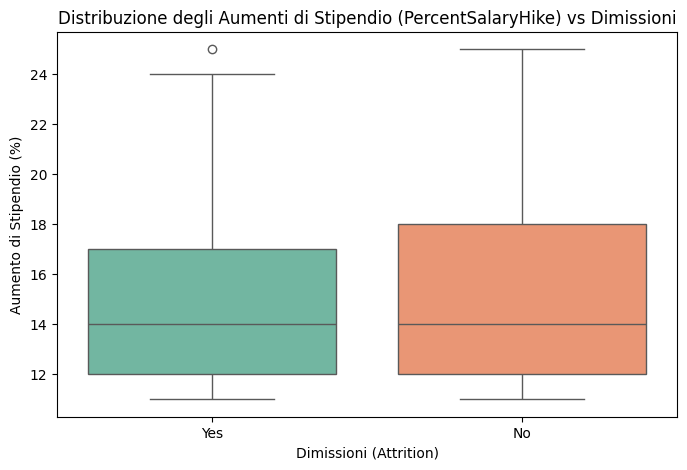

In [ ]:
plt.figure(figsize=(8, 5))

# Boxplot: Attrition vs Aumento percentuale
sns.boxplot(x='Attrition', y='PercentSalaryHike', data=dataset, palette='Set2')

plt.title('Distribuzione degli Aumenti di Stipendio (PercentSalaryHike) vs Dimissioni')
plt.xlabel('Dimissioni (Attrition)')
plt.ylabel('Aumento di Stipendio (%)')

plt.show()

Osservando, notiamo che la differenza non è così marcata come potremmo aspettarci. Entrambi i gruppi ricevono aumenti simili (la mediana è vicina al 14%). Questo ci dice visivamente che un piccolo aumento percentuale non basta a "comprare" la fedeltà di un dipendente se ci sono altri problemi alla base.

### Il Work-Life Balance: chi ha una vita privata pessima scappa di più?
Ipotizziamo che i dipendenti con un pessimo equilibrio tra lavoro e vita privata abbiano un tasso percentuale di dimissioni molto più alto rispetto a chi ha un equilibrio eccellente (4).
Utilizziamo un Barplot per raggruppare i dipendenti e visualizzare la percentuale media di abbandono per ciascun livello.

/tmp/ipykernel_5845/341295724.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='WorkLifeBalance', y='Attrition_Perc', data=dataset, palette='Blues', errorbar=None)


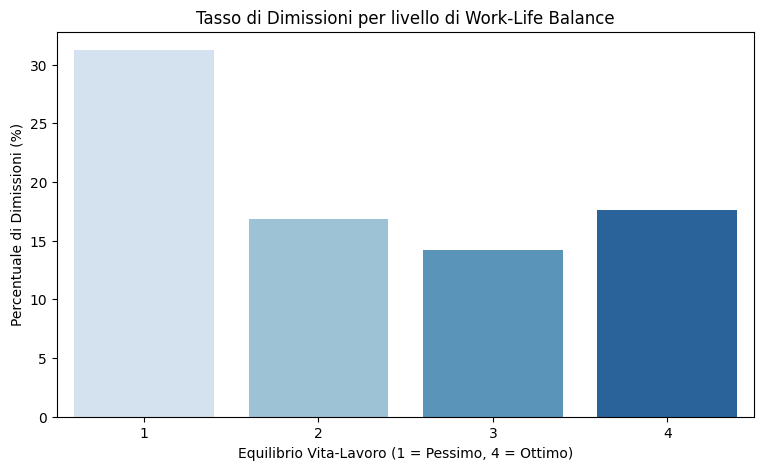

In [ ]:
plt.figure(figsize=(9, 5))

# Creiamo una colonna temporanea che vale 100 se Attrition è "Yes", e 0 se è "No".
# In questo modo, la media calcolata dal barplot corrisponderà esattamente alla percentuale
dataset['Attrition_Perc'] = (dataset['Attrition'] == 'Yes').astype(int) * 100

# Creiamo il Barplot
sns.barplot(x='WorkLifeBalance', y='Attrition_Perc', data=dataset, palette='Blues', errorbar=None)

# Formattazione del grafico
plt.title('Tasso di Dimissioni per livello di Work-Life Balance')
plt.xlabel('Equilibrio Vita-Lavoro (1 = Pessimo, 4 = Ottimo)')
plt.ylabel('Percentuale di Dimissioni (%)')

plt.show()

Il grafico a barre dimostra l'ipotesi in modo lampante: i dipendenti con un Work-Life Balance Pessimo (Livello 1) si dimettono con un tasso che supera il 30%. Man mano che la qualità della vita privata sale (livelli 2, 3 e 4), il tasso di abbandono si dimezza, crollando e stabilizzandosi sotto il 15%.

### Esiste una "Zona Rossa" combinando il mancato coinvolgimento e l'assenza di benefit?
Ipotizziamo che le dimissioni esplodano quando si combinano due fattori negativi: un basso coinvolgimento psicologico nel lavoro e l'assenza totale di benefit finanziari a lungo termine.
Utilizziamo una Heatmap. Incrociamo il livello di coinvolgimento con il livello di azioni aziendali per scoprire dove si concentra il tasso di dimissioni più alto.

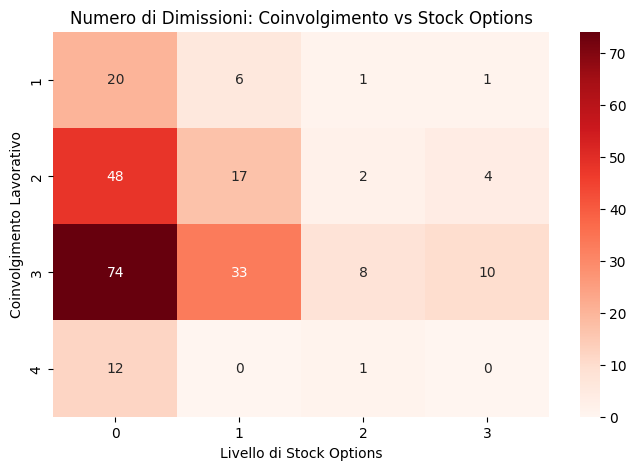

In [ ]:
# 1. Filtriamo il dataset prendendo solo i dipendenti che si sono dimessi
dimessi = dataset[dataset['Attrition'] == 'Yes']

# 2. Usiamo crosstab per contare quanti dipendenti dimessi ci sono per ogni incrocio
tabella_conteggi = pd.crosstab(dimessi['JobInvolvement'], dimessi['StockOptionLevel'])

# 3. Facciamo la heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(tabella_conteggi, annot=True, cmap='Reds', fmt='d')

plt.title('Numero di Dimissioni: Coinvolgimento vs Stock Options')
plt.xlabel('Livello di Stock Options')
plt.ylabel('Coinvolgimento Lavorativo')
plt.show()

Osservando i colori della mappa, notiamo immediatamente che la prima colonna a sinistra (Stock Option = 0) è la più scura in assoluto. Il picco massimo dei numeri assoluti si trova all'incrocio con il Coinvolgimento a livello 3.
Questo dato è estremamente interessante: poiché la stragrande maggioranza dei dipendenti dell'azienda parte da un livello di coinvolgimento medio-alto (livello 3), è normale che il volume maggiore si trovi lì. Tuttavia, il grafico ci dà un responso netto: non importa quanto un dipendente sia coinvolto nel suo lavoro, se l'azienda non gli concede benefit finanziari a lungo termine, il rischio di perderlo è altissimo. Non appena si passa al livello 1 di Stock Options, i colori si schiariscono drasticamente e le dimissioni crollano.

### L'esperienza lavorativa totale è collegata alle dimissioni?

Analizziamo la distribuzione degli anni di esperienza lavorativa totale confrontando i dipendenti che hanno lasciato l'azienda con quelli che sono rimasti. Il grafico permette di osservare se le dimissioni si concentrano in particolari livelli di esperienza.

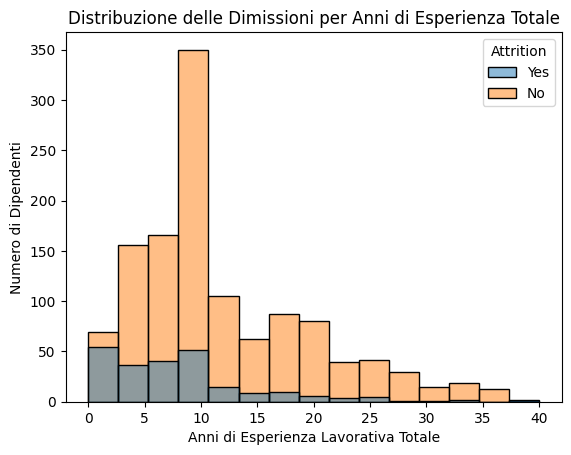

In [ ]:
# Creo l'histplot raggruppando i dati in 15 bins
sns.histplot(data=dataset, x='TotalWorkingYears', hue='Attrition', bins=15)

# Aggiungo il titolo
plt.title("Distribuzione delle Dimissioni per Anni di Esperienza Totale")
plt.xlabel("Anni di Esperienza Lavorativa Totale")
plt.ylabel("Numero di Dipendenti")

plt.show()

L'istogramma risolve il problema della sovrapposizione dei dati e ci offre una visione inequivocabile del fenomeno. Osservando la distribuzione, emergono due dinamiche fondamentali:

- Ci sono tante dimissioni concentrate nella primissima fascia di esperienza lavorativa. Il picco assoluto di abbandoni si registra tra i dipendenti che hanno tra 0 e 10 anni di esperienza totale, con la massima intensità nei primissimi anni.
- Man mano che l'esperienza totale cresce (spostandoci verso destra), il volume delle dimissioni crolla drasticamente. Superati i 15 anni di carriera, la barra delle dimissioni diventa quasi invisibile rispetto alla barra di chi resta.

Questo grafico conferma la nostra ipotesi: i profili giovani sono di gran lunga i più instabili e propensi a cambiare aria (spesso per accelerare la carriera lavorativa), mentre l'acquisizione di profili "Senior" garantisce all'azienda una fedeltà altissima.

#FASE 4: Modellazione

Importiamo le librerie per preparare i dati e addestrare i modelli.

In [ ]:
# Librerie per la modellazione
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

Abbiamo importato gli strumenti necessari per train/test split, standardizzazione e modelli di classificazione.

Prepariamo il dataset per la classificazione.

In [ ]:
# Creiamo una copia del dataset originale
df_model = dataset.copy()

# Convertiamo la variabile target in numerica
df_model["Attrition"] = df_model["Attrition"].map({
    "No": 0,
    "Yes": 1
})

# Separiamo target e feature
y = df_model["Attrition"]

X = df_model.drop(columns=[
    "Attrition",
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
], errors="ignore")

# Convertiamo le variabili categoriche in numeriche
X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Numero di righe:", X.shape[0])
print("Numero di feature dopo la codifica:", X.shape[1])

Numero di righe: 1470
Numero di feature dopo la codifica: 44


La target è stata trasformata in 0/1, le variabili categoriche sono state convertite in numeriche e le colonne poco informative sono state escluse.

Dividiamo i dati in training set e test set.

In [ ]:
# Dividiamo il dataset in training set e test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1029, 44)
Test set: (441, 44)


Il training set sarà usato per addestrare i modelli, mentre il test set sarà usato nella fase successiva per valutarli.

Standardizziamo le variabili.

In [ ]:
# Standardizziamo le feature per i modelli sensibili alla scala
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Riconvertiamo per mantenere i nomi delle colonne
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
853,-1.958919,-0.413973,-0.036578,-0.866067,0.270496,-0.547908,0.37805,-0.998363,-1.538894,-0.867017,...,-0.463547,-0.278365,-0.329903,-0.235339,2.068072,-0.550029,-0.230704,-0.929586,1.475102,-0.644520
435,-0.430695,1.176070,0.699024,-1.835797,-0.651162,-0.449557,0.37805,0.846010,0.264662,1.532088,...,-0.463547,3.592409,-0.329903,-0.235339,-0.483542,-0.550029,-0.230704,1.075748,-0.677919,1.551543
587,1.643324,1.296833,0.208623,1.073395,1.192155,0.829007,0.37805,-0.076177,0.264662,-0.737494,...,2.157277,-0.278365,-0.329903,-0.235339,-0.483542,-0.550029,-0.230704,1.075748,-0.677919,-0.644520
1170,-1.085648,-0.549831,-0.894779,0.103664,1.192155,1.074884,0.37805,-0.998363,1.166440,-0.860942,...,-0.463547,-0.278365,-0.329903,-0.235339,2.068072,-0.550029,-0.230704,-0.929586,1.475102,-0.644520
159,-0.321536,-1.274408,-0.894779,1.073395,0.270496,0.484778,0.37805,-0.998363,0.264662,-0.936660,...,-0.463547,-0.278365,-0.329903,-0.235339,-0.483542,-0.550029,4.334566,1.075748,-0.677919,-0.644520


La standardizzazione serve soprattutto per regressione logistica e k-NN, perché questi modelli sono influenzati dalla scala delle variabili.

##Regressione logistica

In [ ]:
# Modello 1: Regressione Logistica
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_train_scaled, y_train)

pred_log_reg = log_reg.predict(X_test_scaled)

print("Modello Regressione Logistica addestrato.")

Modello Regressione Logistica addestrato.


##K-NN

In [ ]:
# Modello 2: k-NN
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

print("Modello k-NN addestrato.")

Modello k-NN addestrato.


Il k-NN è un modello non lineare che classifica i dipendenti in base ai casi più simili.

##Random Forest

In [ ]:
# Modello 3: Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Modello Random Forest addestrato.")

Modello Random Forest addestrato.


La Random Forest è un modello non lineare basato su molti alberi decisionali. In questo caso non serve standardizzare le variabili.

Salviamo le predizioni dei tre modelli.

In [ ]:
# Salviamo le predizioni dei modelli per la fase di valutazione
predizioni_modelli = {
    "Regressione Logistica": pred_log_reg,
    "k-NN": pred_knn,
    "Random Forest": pred_rf
}

print("Predizioni salvate per la Fase 5.")

Predizioni salvate per la Fase 5.


Le predizioni saranno usate nella Fase 5 per calcolare accuracy, confusion matrix, precision, recall e f1-score.

#FASE 5: Valutazione e interpretazione dei risultati


Importiamo le metriche richieste per valutare i modelli.

In [ ]:
# Importiamo le metriche per valutare i modelli
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

Le metriche serviranno per confrontare le prestazioni dei modelli sul test set.

Creiamo una funzione unica per valutare tutti i modelli nello stesso modo.

In [ ]:
# Funzione per calcolare le metriche principali di ogni modello
def valuta_modello(nome_modello, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    matrice = confusion_matrix(y_test, y_pred)

    print("Modello:", nome_modello)
    print("Accuracy:", round(accuracy, 3))
    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))
    print("F1-score:", round(f1, 3))
    print("\nConfusion matrix:")
    print(matrice)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

La funzione calcola automaticamente accuracy, precision, recall, f1-score e confusion matrix.

##Valutazione regressione logistica

In [ ]:
# Valutiamo la Regressione Logistica
valuta_modello("Regressione Logistica", y_test, pred_log_reg)

Modello: Regressione Logistica
Accuracy: 0.88
Precision: 0.725
Recall: 0.408
F1-score: 0.523

Confusion matrix:
[[359  11]
 [ 42  29]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       370
           1       0.72      0.41      0.52        71

    accuracy                           0.88       441
   macro avg       0.81      0.69      0.73       441
weighted avg       0.87      0.88      0.87       441



La regressione logistica ottiene una buona accuracy complessiva pari a 0.88, ma il risultato va letto con attenzione perché il dataset è sbilanciato. Il modello riconosce molto bene i dipendenti rimasti in azienda, mentre individua solo 29 dei 71 dipendenti che hanno lasciato, con una recall per la classe 1 pari a 0.408. Questo significa che il modello è abbastanza preciso quando prevede un abbandono, ma tende a non riconoscere diversi casi reali di dimissioni.


##Valutazione k-NN

In [ ]:
# Valutiamo il modello k-NN
valuta_modello("k-NN", y_test, pred_knn)

Modello: k-NN
Accuracy: 0.839
Precision: 0.5
Recall: 0.07
F1-score: 0.123

Confusion matrix:
[[365   5]
 [ 66   5]]

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       370
           1       0.50      0.07      0.12        71

    accuracy                           0.84       441
   macro avg       0.67      0.53      0.52       441
weighted avg       0.79      0.84      0.78       441



Il modello k-NN ottiene un’accuracy pari a 0.839, ma fatica molto a riconoscere i dipendenti che lasciano l’azienda. Infatti individua correttamente solo 5 casi di abbandono su 71, con una recall molto bassa pari a 0.07. Questo indica che il modello tende quasi sempre a prevedere la classe maggioritaria, cioè i dipendenti rimasti in azienda.


##Valutazione Random Forest

In [ ]:
# Valutiamo la Random Forest
valuta_modello("Random Forest", y_test, pred_rf)

Modello: Random Forest
Accuracy: 0.834
Precision: 0.455
Recall: 0.141
F1-score: 0.215

Confusion matrix:
[[358  12]
 [ 61  10]]

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       370
           1       0.45      0.14      0.22        71

    accuracy                           0.83       441
   macro avg       0.65      0.55      0.56       441
weighted avg       0.79      0.83      0.80       441



La Random Forest ottiene un’accuracy pari a 0.834, ma riconosce pochi casi di abbandono: individua correttamente solo 10 dipendenti dimessi su 71. La recall della classe 1 è quindi bassa, pari a 0.141, mostrando che anche questo modello tende a prevedere soprattutto i dipendenti rimasti in azienda.


Abbiamo mantenuto uno split 70/30 tra training set e test set. Anche se con uno split 50/50 alcune metriche risultavano migliori, questa scelta avrebbe ridotto troppo i dati disponibili per l’addestramento e avrebbe potuto rendere il confronto meno affidabile. Per questo motivo preferiamo usare uno split più standard, lasciando il 70% dei dati al training e il 30% alla valutazione. Invece, provando a diminuire a 0.20 o 0.10, il risultato è che ridurre troppo il test set potrebbe aumentare i dati disponibili per il training, ma renderebbe precision e recall meno affidabili, soprattutto perché la classe dei dipendenti dimessi è poco numerosa.

##Approfondimenti

###Coefficienti (regressione logistica)

In [ ]:
# Regressione logistica con una sola variabile: OverTime

X_log = X_train[["OverTime_Yes"]]
y_log = y_train

log_model = LogisticRegression()
log_model.fit(X_log, y_log)

coef = log_model.coef_[0][0]
intercept = log_model.intercept_[0]

coef, intercept

(np.float64(1.1350262161277076), np.float64(-2.074456742710321))

Il coefficiente di `OverTime_Yes` è positivo, quindi nel modello chi fa straordinari ha una maggiore probabilità stimata di lasciare l’azienda rispetto a chi non li fa. L’intercetta negativa rappresenta invece il valore di base del modello quando `OverTime_Yes` è pari a 0, cioè per i dipendenti che non fanno straordinari.


###Feature importance (RF)

In [ ]:
# Analizziamo l'importanza delle feature nella Random Forest
importanza_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importanza": rf.feature_importances_
})

importanza_rf = importanza_rf.sort_values(
    by="Importanza",
    ascending=False
)

importanza_rf.head(10)

,Feature,Importanza
9,MonthlyIncome,0.079422
0,Age,0.063437
16,TotalWorkingYears,0.056514
1,DailyRate,0.051529
5,HourlyRate,0.048064
10,MonthlyRate,0.047042
2,DistanceFromHome,0.043657
19,YearsAtCompany,0.041499
22,YearsWithCurrManager,0.039863
43,OverTime_Yes,0.039287


La Random Forest attribuisce maggiore importanza a variabili legate allo stipendio, all’età e all’esperienza lavorativa, come `MonthlyIncome`, `Age` e `TotalWorkingYears`. Anche `OverTime_Yes` rientra tra le feature più rilevanti, confermando che gli straordinari sono una variabile utile per prevedere l’abbandono. Questi valori indicano quali feature il modello usa di più, ma non dimostrano necessariamente un rapporto di causa-effetto.
